C:\Users\LucAA\AppData\Local\Temp\ipykernel_6472\391745973.py:20: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  roi = img * mask3d


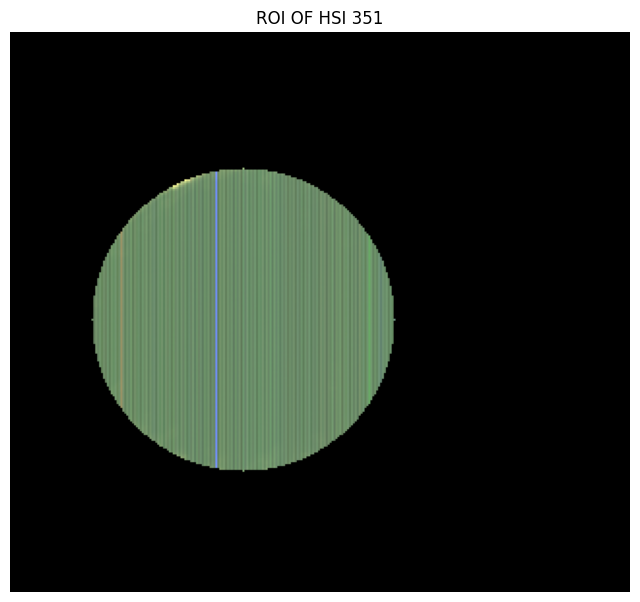

In [7]:
import spectral
import cv2
import numpy as np
import matplotlib.pyplot as plt

caminho =  r"C:\Users\LucAA\Documents\GitHub\IC_2025\Ic2025\data_processed\351_1_240506-160920.hdr"

img = spectral.open_image(caminho).load()
rgb = spectral.get_rgb(img,[50,30, 10])

gray = cv2.cvtColor((rgb *255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
gray = cv2.GaussianBlur(gray,(7,7),2)

circles = cv2.HoughCircles(gray,cv2.HOUGH_GRADIENT,1.2,100,param1=100,param2=30,minRadius=50,maxRadius=200)
mask = np.zeros(gray.shape,dtype=np.uint8)
x,y,r= circles[0][0]
cv2.circle(mask,(int(x),int(y)),int(r),1,thickness=-1)

mask3d = np.repeat(mask[:,:,np.newaxis],img.shape[2],axis=2)
roi = img * mask3d

roi_rgb = spectral.get_rgb(roi, [50, 30, 10])

plt.figure(figsize=(8,8))
plt.imshow(roi_rgb)
plt.axis("off")
plt.title("ROI OF HSI 351")
plt.show()


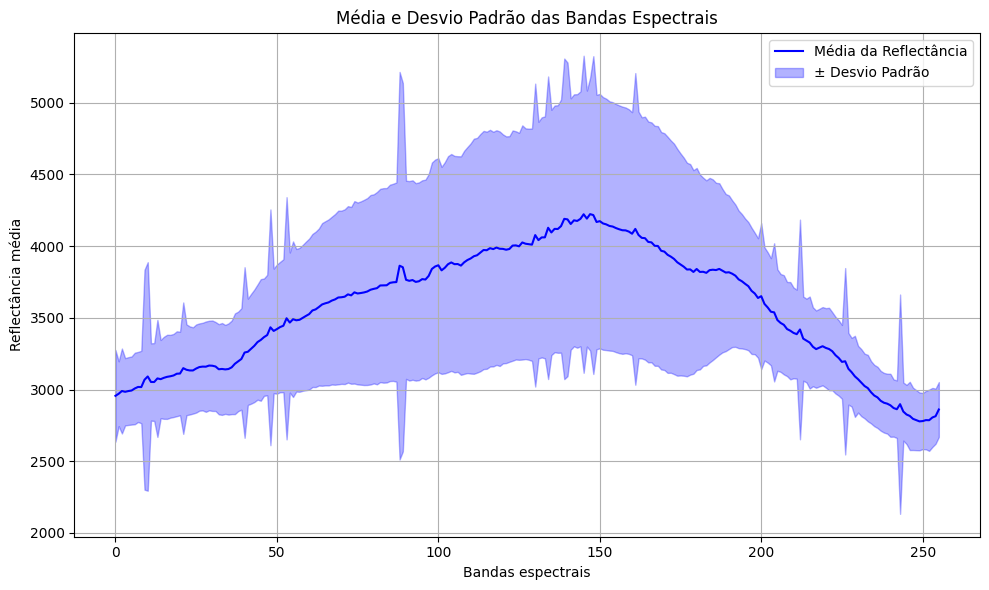

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from spectral import open_image


caminho_imagem = r"C:\Users\LucAA\Documents\GitHub\IC_2025\Ic2025\data_processed\351_1_240506-160920.hdr"

img = open_image(caminho_imagem).load()

mean_spectrum = img.mean(axis=(0, 1))  
std_spectrum = img.std(axis=(0, 1))    


num_bandas = img.shape[2]
bandas = np.arange(num_bandas)  

plt.figure(figsize=(10, 6))
plt.plot(bandas, mean_spectrum, label='Média da Reflectância', color='blue')
plt.fill_between(bandas, mean_spectrum - std_spectrum, mean_spectrum + std_spectrum,
                 color='blue', alpha=0.3, label='± Desvio Padrão')
plt.xlabel('Bandas espectrais')
plt.ylabel('Reflectância média')
plt.title('Média e Desvio Padrão das Bandas Espectrais')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
